<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista6-MateuszOlech/blob/main/Lista6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista 6

In [83]:
# IMPORTY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from imblearn.metrics import classification_report_imbalanced

warnings.filterwarnings('ignore')

## Zadanie 1.1: Pobranie Danych i EDA
- Pobierz zbiór danych Speed Dating korzystając z sklearn.datasets.fetch_openml (id=40536).
- Wykonaj analizę danych i wygeneruj wizualizacje. Zwróć szczególną uwagę na rozkład zmiennych i zależności między nimi.

In [46]:
speed_dating = fetch_openml(data_id=40536, as_frame=True, parser='auto')
df = speed_dating.data
df['match'] = speed_dating.target
df.head()

,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


In [47]:
# INFO
print(f"Rozmiar: {df.shape[0]} wierszy, {df.shape[1]} kolumn.\n{20*'-'}")
print(f"Kolumny: {list(df.columns)}\n{20*'-'}")
print(f"Typy danych:")
print(df.dtypes)


Rozmiar: 8378 wierszy, 121 kolumn.
--------------------
Kolumny: ['has_null', 'wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o', 'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_impor

Text(0, 0.5, 'Liczność klasy')

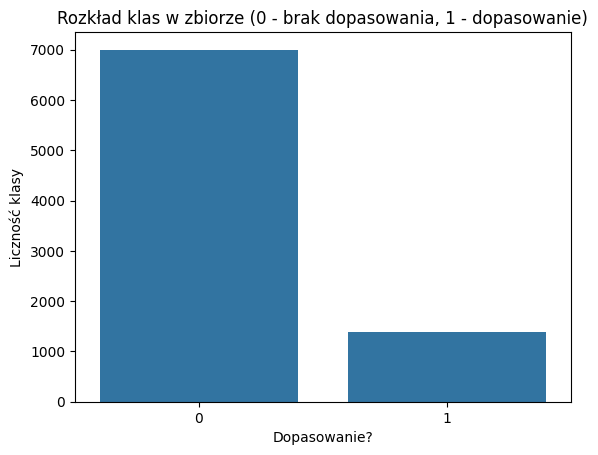

In [48]:
sns.countplot(
    data=df,
    x='match'
)
plt.title("Rozkład klas w zbiorze (0 - brak dopasowania, 1 - dopasowanie)")
plt.xlabel("Dopasowanie?")
plt.ylabel("Liczność klasy")

In [49]:
df['gender'] = df['gender'].map({1: 'male', 0: 'female'})

In [50]:
# USUNIĘCIĘ WIEDZY "Z PRZYSZŁOŚCI"
columns_to_drop = [
    'decision', 'decision_o', 'met', 'guess_prob_liked', 'like', 'interests_correlate',
    'd_like', 'd_guess_prob_liked', 'd_interests_correlate',
    'attractive_o', 'sinsere_o', 'intelligence_o', 'funny_o', 'ambitous_o', 'shared_interests_o',
    'd_attractive_o', 'd_sinsere_o', 'd_intelligence_o', 'd_funny_o', 'd_ambitous_o', 'd_shared_interests_o',
    'attractive_partner', 'sincere_partner', 'intelligence_partner', 'funny_partner', 'ambition_partner', 'shared_interests_partner',
    'd_attractive_partner', 'd_sincere_partner', 'd_intelligence_partner', 'd_funny_partner', 'd_ambition_partner', 'd_shared_interests_partner',
    'has_null',
    'expected_happy_with_sd_people', 'expected_num_interested_in_me', 'expected_num_matches',
    'd_expected_happy_with_sd_people', 'd_expected_num_interested_in_me', 'd_expected_num_matches'
]

df = df.drop(columns=columns_to_drop, errors='ignore')
cols = [col for col in df.columns]
print(cols)

['wave', 'gender', 'age', 'age_o', 'd_age', 'd_d_age', 'race', 'race_o', 'samerace', 'importance_same_race', 'importance_same_religion', 'd_importance_same_race', 'd_importance_same_religion', 'field', 'pref_o_attractive', 'pref_o_sincere', 'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious', 'pref_o_shared_interests', 'd_pref_o_attractive', 'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny', 'd_pref_o_ambitious', 'd_pref_o_shared_interests', 'attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'd_attractive_important', 'd_sincere_important', 'd_intellicence_important', 'd_funny_important', 'd_ambtition_important', 'd_shared_interests_important', 'attractive', 'sincere', 'intelligence', 'funny', 'ambition', 'd_attractive', 'd_sincere', 'd_intelligence', 'd_funny', 'd_ambition', 'sports', 'tvsports', 'exercise', 'dining', 'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading',

Text(0.5, 1.0, 'Macierz korelacji')

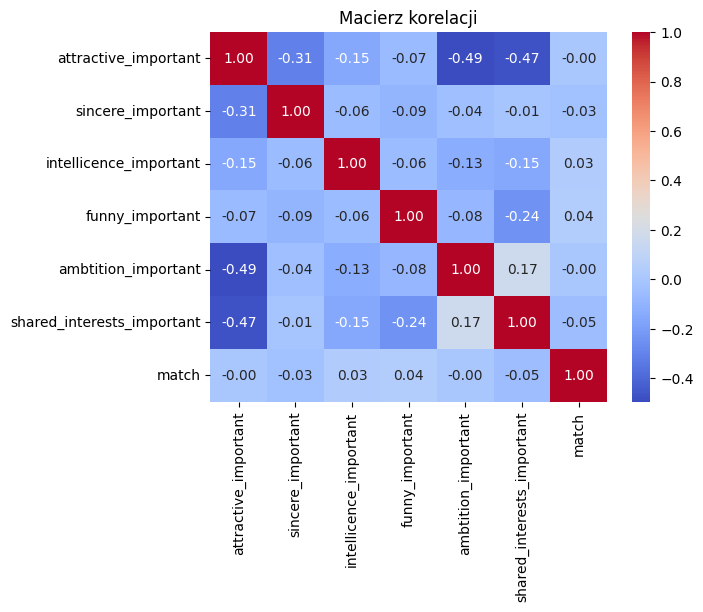

In [51]:
# MACIERZ KORELACJI
cols_to_matrix = ['attractive_important', 'sincere_important', 'intellicence_important', 'funny_important', 'ambtition_important', 'shared_interests_important', 'match']
corr_matrix = df[cols_to_matrix].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")

Text(0.5, 1.0, 'Macierz korelacji')

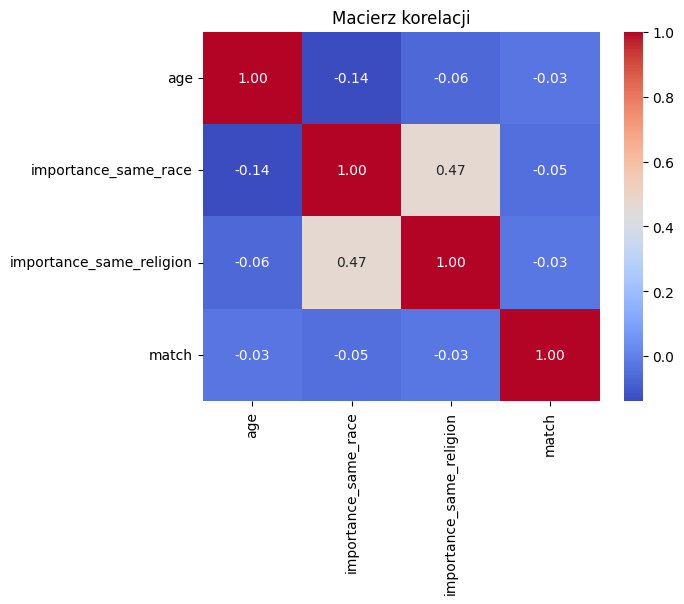

In [52]:
cols_to_matrix = ['age', 'importance_same_race', 'importance_same_religion', 'match']
corr_matrix = df[cols_to_matrix].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")

In [53]:
# CYFROWY ODCISK PALCA
profile_features = ['wave', 'gender', 'age', 'race', 'importance_same_race', 'importance_same_religion']

temp_df = df[profile_features].astype(str)
df['user_id'] = temp_df.groupby(profile_features).ngroup()

user_counts = df['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
df_filtered = df[df['user_id'].isin(valid_users)].copy()

unique_users = df_filtered['user_id'].unique()

train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)

df_train = df_filtered[df_filtered['user_id'].isin(train_users)].copy()
df_test_full = df_filtered[df_filtered['user_id'].isin(test_users)].copy()

df_test = df_test_full.groupby('user_id').sample(n=5, random_state=42).copy()

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

train_ids = df_train.pop('user_id')
test_ids = df_test.pop('user_id')

y_train = df_train.pop('match').astype(int)
y_test = df_test.pop('match').astype(int)

X_train = df_train
X_test = df_test

print(f"Dane treningowe (X_train): {X_train.shape}")
print(f"Dane testowe (X_test):  {X_test.shape}")

Dane treningowe (X_train): (6675, 82)
Dane testowe (X_test):  (545, 82)


In [54]:
missing = df.isnull().sum()
df_missing = pd.DataFrame({'Liczba braków': missing, 'Rodzaj kolumny': df.dtypes})
df_missing = df_missing[df_missing['Liczba braków'] > 0]
print(f"Braki danych:")
print(df_missing)

Braki danych:
                            Liczba braków Rodzaj kolumny
gender                               8378        float64
age                                    95        float64
age_o                                 104        float64
race                                   63       category
race_o                                 73       category
importance_same_race                   79        float64
importance_same_religion               79        float64
field                                  63       category
pref_o_attractive                      89        float64
pref_o_sincere                         89        float64
pref_o_intelligence                    89        float64
pref_o_funny                           98        float64
pref_o_ambitious                      107        float64
pref_o_shared_interests               129        float64
attractive_important                   79        float64
sincere_important                      79        float64
intellicence_impo

In [55]:
# UZUPEŁNIANIE BRAKÓW
num_cols = X_train.select_dtypes(include=[np.number]).columns
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train_num_array = num_imputer.fit_transform(X_train[num_cols])
survived_num_cols = num_imputer.get_feature_names_out(num_cols)

X_train_num = pd.DataFrame(X_train_num_array, columns=survived_num_cols)
X_test_num = pd.DataFrame(num_imputer.transform(X_test[num_cols]), columns=survived_num_cols)

X_train_cat_array = cat_imputer.fit_transform(X_train[cat_cols])
survived_cat_cols = cat_imputer.get_feature_names_out(cat_cols)

X_train_cat = pd.DataFrame(X_train_cat_array, columns=survived_cat_cols)
X_test_cat = pd.DataFrame(cat_imputer.transform(X_test[cat_cols]), columns=survived_cat_cols)

X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)

print(X_train.isnull().sum())

wave                    0
age                     0
age_o                   0
d_age                   0
importance_same_race    0
                       ..
d_movies                0
d_concerts              0
d_music                 0
d_shopping              0
d_yoga                  0
Length: 81, dtype: int64


In [57]:
print(X_train.columns)

Index(['wave', 'age', 'age_o', 'd_age', 'importance_same_race',
       'importance_same_religion', 'pref_o_attractive', 'pref_o_sincere',
       'pref_o_intelligence', 'pref_o_funny', 'pref_o_ambitious',
       'pref_o_shared_interests', 'attractive_important', 'sincere_important',
       'intellicence_important', 'funny_important', 'ambtition_important',
       'shared_interests_important', 'attractive', 'sincere', 'intelligence',
       'funny', 'ambition', 'sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga', 'd_d_age',
       'race', 'race_o', 'samerace', 'd_importance_same_race',
       'd_importance_same_religion', 'field', 'd_pref_o_attractive',
       'd_pref_o_sincere', 'd_pref_o_intelligence', 'd_pref_o_funny',
       'd_pref_o_ambitious', 'd_pref_o_shared_interests',
       'd_attractive_important', 'd_sincere_important',
       'd_intellicence

In [66]:
# NOWE CECHY
def new_features(df):
  df_new = df.copy()
  # 1. wskaźnik samooceny
  cols_to_self_esteem = ['attractive','sincere','intelligence','funny','ambition']
  df_new['self_esteem'] = df_new[cols_to_self_esteem].sum(axis=1)

  # 2. powierzchowność
  df_new['superficiality'] = df_new['attractive_important'] / (df_new['intellicence_important'] + df_new['sincere_important'] + 0.0001)

  # 3. różnica atrakcyjności
  df_new['diff_attract'] = df_new['attractive_important'] - df_new['attractive']

  # 4. entuzjasta hobby
  hobby_cols = ['sports', 'tvsports', 'exercise', 'dining',
       'museums', 'art', 'hiking', 'gaming', 'clubbing', 'reading', 'tv',
       'theater', 'movies', 'concerts', 'music', 'shopping', 'yoga']
  df_new['hobby_enthusiasm'] = df_new[hobby_cols].mean(axis=1)
  return df_new

X_train = new_features(X_train)
X_test = new_features(X_test)
df = new_features(df)

Text(0.5, 1.0, 'Macierz korelacji')

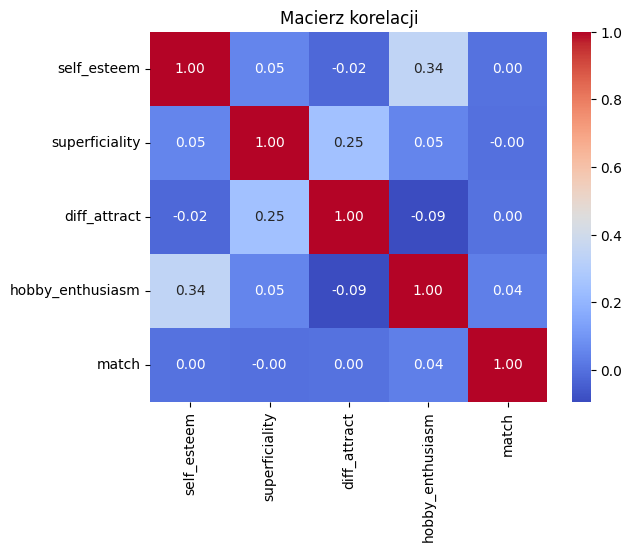

In [67]:
cols_to_matrix = ['self_esteem', 'superficiality', 'diff_attract', 'hobby_enthusiasm', 'match']
corr_matrix = df[cols_to_matrix].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Macierz korelacji")

In [69]:
# NAIWNE MODELE - WIĘKSZOŚCIOWY I LOSOWY
majority_classifier = DummyClassifier(strategy='most_frequent')
majority_classifier.fit(X_train, y_train)
y_pred_majority = majority_classifier.predict(X_test)

print("=== PREDYKATOR WIĘKSZOŚCIOWY ===")
print(classification_report_imbalanced(y_test, y_pred_majority))

=== PREDYKATOR WIĘKSZOŚCIOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      1.00      0.00      0.93      0.00      0.00       477
          1       0.00      0.00      1.00      0.00      0.00      0.00        68

avg / total       0.77      0.88      0.12      0.82      0.00      0.00       545



In [70]:
random_classifier = DummyClassifier(strategy='stratified', random_state=42)
random_classifier.fit(X_train, y_train)
y_pred_random = random_classifier.predict(X_test)

print("=== PREDYKATOR LOSOWY ===")
print(classification_report_imbalanced(y_test, y_pred_random))


=== PREDYKATOR LOSOWY ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.87      0.81      0.18      0.84      0.38      0.15       477
          1       0.12      0.18      0.81      0.14      0.38      0.13        68

avg / total       0.78      0.73      0.26      0.75      0.38      0.15       545



In [73]:
# ENCODING
X_train_encoded = pd.get_dummies(X_train, drop_first=True, dtype=float)
X_test_encoded = pd.get_dummies(X_test, drop_first=True, dtype=float)
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0.0)


In [88]:
# DRZEWO DECYZYJNE
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train_encoded, y_train)
y_pred_tree = tree_model.predict(X_test_encoded)

print("=== DRZEWO DECYZYJNE ===")
print(classification_report_imbalanced(y_test, y_pred_tree))

=== DRZEWO DECYZYJNE ===
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.98      0.06      0.93      0.24      0.06       477
          1       0.31      0.06      0.98      0.10      0.24      0.05        68

avg / total       0.81      0.87      0.17      0.82      0.24      0.06       545



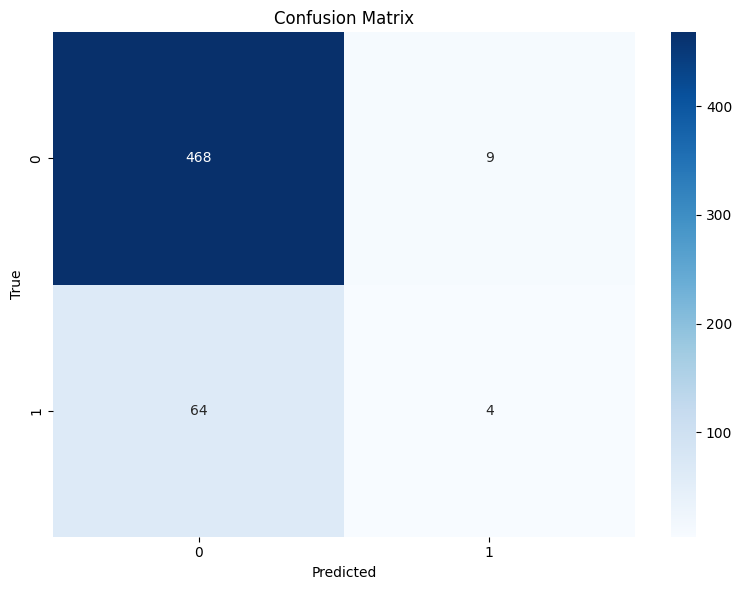

In [98]:
conf_matrix = confusion_matrix(y_test, y_pred_tree)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


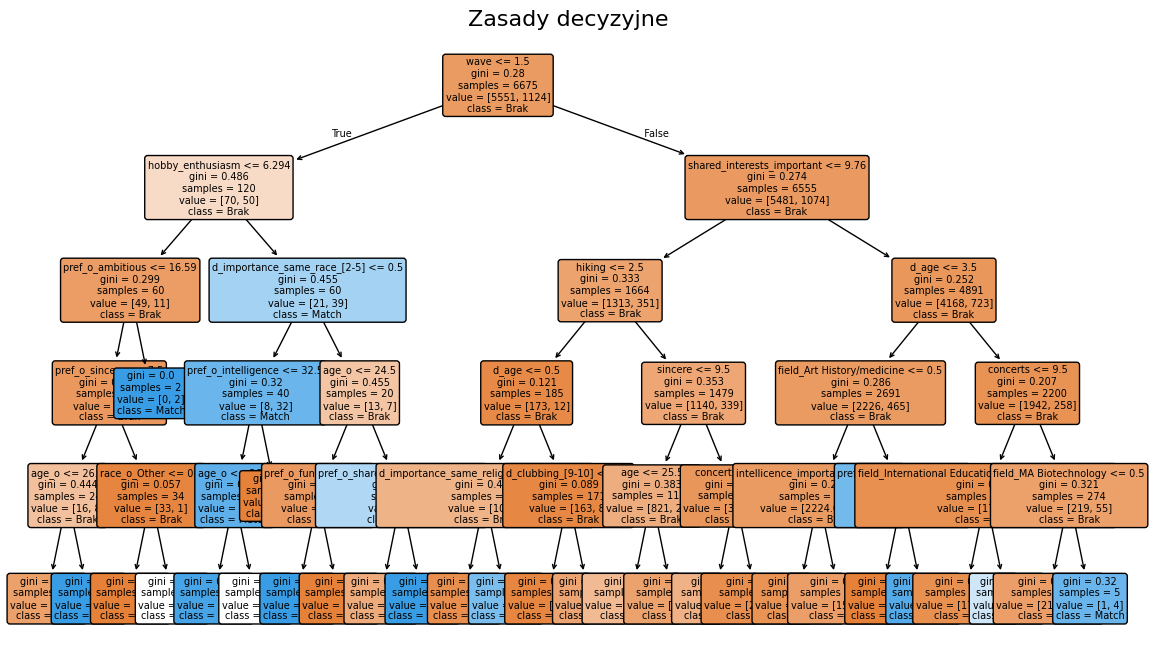

In [97]:
plt.figure(figsize=(14, 8))
plot_tree(tree_model,
          feature_names=X_train_encoded.columns,
          class_names=['Brak', 'Match'],
          filled=True,
          rounded=True,
          fontsize=7)

plt.title("Zasady decyzyjne", fontsize=16)
plt.show()